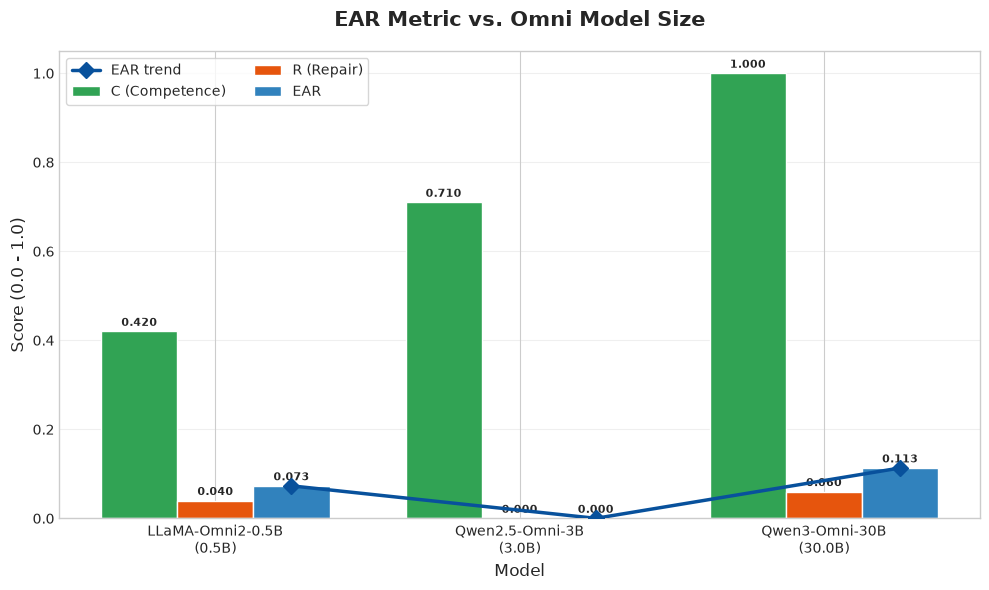

In [4]:
# Plot: C / R / EAR across the 3 evaluated omni models
import json
import numpy as np
import matplotlib.pyplot as plt

# (label, size in B, results jsonl path) -- ordered by size; edit paths if yours differ
MODELS = [
    ("LLaMA-Omni2-0.5B", 0.5, "ear_results_llama_omni2.jsonl"),
    ("Qwen2.5-Omni-3B",  3.0, "ear_results_qwen25.jsonl"),
    ("Qwen3-Omni-30B",  30.0, "ear_results_Qwen3-Omni-30B-A3B-Instruct.jsonl"),
]

def load_summary(path):
    """Return (C, R, EAR) from the last JSONL line that contains an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:                 # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return float(summary["C"]), float(summary["R"]), float(summary["EAR"])

labels = [m[0] for m in MODELS]
sizes  = [m[1] for m in MODELS]
C, R, EAR = zip(*[load_summary(m[2]) for m in MODELS])

x = np.arange(len(MODELS))
width = 0.25

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

bars_c   = ax.bar(x - width, C,   width, label="C (Competence)", color="#31a354", edgecolor="white")
bars_r   = ax.bar(x,         R,   width, label="R (Repair)",     color="#e6550d", edgecolor="white")
bars_ear = ax.bar(x + width, EAR, width, label="EAR",            color="#3182bd", edgecolor="white")

# EAR trend line across model sizes
ax.plot(x + width, EAR, color="#08519c", marker="D", linestyle="-",
        linewidth=2.5, markersize=8, label="EAR trend", zorder=5)

# annotate every bar
for bars in (bars_c, bars_r, bars_ear):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, fontweight="bold")

ax.set_title("EAR Metric vs. Omni Model Size", fontsize=15, pad=18, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (0.0 - 1.0)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{lab}\n({s}B)" for lab, s in zip(labels, sizes)], fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=10, frameon=True, ncol=2)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
# Build a LaTeX table (paper-style, booktabs) of C / R / EAR on SLURP.
# Reads the summary line (last JSONL record containing "EAR") from each result file,
# scales scores to percentages (x100, 1 decimal), bolds the best value per column,
# and prints LaTeX you can paste straight into Overleaf.

import json

# ---- EDIT THESE PATHS -------------------------------------------------------
# Use None for models that don't have a result file yet (rendered as TBD).
FILES = {
    "LLaMA-Omni2-0.5B":      None,                                  # TBD, no file yet
    "Qwen2.5-Omni-3B":       "ear_results_Qwen2.5-Omni-3B_slurp.jsonl",            # <-- fill in
    "Qwen3-Omni-30B":        "ear_results_Qwen3-Omni-30B-A3B-Instruct_slurp.jsonl",    # <-- fill in
    "Qwen2.5-Omni-3B (SFT)": "ear_results_Qwen2.5-Omni-3B-ear-sft_slurp.jsonl",        # <-- fill in
    "Qwen2.5-Omni-3B (SFT, ans-token)":
        "ear_results_Qwen2.5-Omni-3B-ear-anstok-sft_anstok_slurp.jsonl",
}
# -----------------------------------------------------------------------------

GROUPS = [
    ("Base Models",
     ["LLaMA-Omni2-0.5B", "Qwen2.5-Omni-3B", "Qwen3-Omni-30B"]),
    (r"Our Model (\textit{Tuning on EAR data with ambiguity})",
     ["Qwen2.5-Omni-3B (SFT)", "Qwen2.5-Omni-3B (SFT, ans-token)"]),
]

METRICS = ["C", "R", "EAR"]


def load_summary(path):
    """Return {'C':..,'R':..,'EAR':..} from the last JSONL line containing an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:  # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return {m: float(summary[m]) for m in METRICS}


# Load scores (values stay None for TBD models)
scores = {model: (load_summary(path) if path else None)
          for model, path in FILES.items()}

# Best value per column, among models that have results
best = {m: max(s[m] for s in scores.values() if s is not None) for m in METRICS}


def fmt(model, metric):
    s = scores[model]
    if s is None:
        return "TBD"
    val = s[metric] * 100.0
    cell = f"{val:.1f}"
    if s[metric] == best[metric]:
        cell = rf"\textbf{{{cell}}}"
    return cell


# ---- Assemble LaTeX ---------------------------------------------------------
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{3}{c}{\textbf{SLURP}} \\")
lines.append(r"\cmidrule(lr){2-4}")
lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & \textbf{EAR}$\uparrow$ \\")

for group_name, models in GROUPS:
    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{4}}{{c}}{{{group_name}}} \\")
    lines.append(r"\midrule")
    for model in models:
        cells = " & ".join(fmt(model, m) for m in METRICS)
        lines.append(rf"{model} & {cells} \\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Repair-aware evaluation results on SLURP. We report task "
             r"competence under answerable inputs ($C$), repair behavior under "
             r"unanswerable inputs ($R$), and the resulting EAR score. The "
             r"ans-token variant is trained to emit a literal "
             r"\texttt{<|answerable|>} marker on answerable inputs; its $C$ is "
             r"exact-match accuracy of that marker rather than judge-scored.}")
lines.append(r"\label{tab:slurp_ear}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

\begin{table}[t]
\centering
\begin{tabular}{lccc}
\toprule
 & \multicolumn{3}{c}{\textbf{SLURP}} \\
\cmidrule(lr){2-4}
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & \textbf{EAR}$\uparrow$ \\
\midrule
\multicolumn{4}{c}{Base Models} \\
\midrule
LLaMA-Omni2-0.5B & TBD & TBD & TBD \\
Qwen2.5-Omni-3B & 70.0 & 27.0 & 39.0 \\
Qwen3-Omni-30B & 80.0 & 6.0 & 11.2 \\
\midrule
\multicolumn{4}{c}{Our Model (\textit{Tuning on EAR data with ambiguity})} \\
\midrule
Qwen2.5-Omni-3B (SFT) & 88.0 & \textbf{79.0} & \textbf{83.3} \\
Qwen2.5-Omni-3B (SFT, ans-token) & \textbf{94.0} & 74.0 & 82.8 \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation results on SLURP. We report task competence under answerable inputs ($C$), repair behavior under unanswerable inputs ($R$), and the resulting EAR score. The ans-token variant is trained to emit a literal \texttt{<|answerable|>} marker on answerable inputs; its $C$ is exact-match accuracy of that marker rather than judge-scored.}
\label{tab:slurp_ear}
\en

In [1]:
# Build a LaTeX table (paper-style, booktabs) of C / R / EAR on SLURP.
# Reads the summary line (last JSONL record containing "EAR") from each result file,
# scales scores to percentages (x100, 1 decimal), bolds the best value per column,
# and prints LaTeX you can paste straight into Overleaf.
import json

# ---- EDIT THESE PATHS -------------------------------------------------------
FILES = {
    "Qwen2.5-Omni-3B":       "bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
    "Qwen2.5-Omni-3B (SFT)": "bab_results_Qwen2.5-Omni-3B-bab-sft-adapter-v2_slurp.jsonl",
}
# -----------------------------------------------------------------------------

GROUPS = [
    ("Base Models",
     ["Qwen2.5-Omni-3B"]),
    (r"Our Model (\textit{Tuning on SLURP data with babble})",
     ["Qwen2.5-Omni-3B (SFT)"]),
]

METRICS = ["C", "R", "F", "EAR"]

def load_summary(path):
    """Return {'C':..,'R':..,'EAR':..} from the last JSONL line containing an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:  # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return {m: float(summary[m]) for m in METRICS}

# Load scores (values stay None for TBD models)
scores = {model: (load_summary(path) if path else None)
          for model, path in FILES.items()}

# Best value per column, among models that have results
best = {m: max(s[m] for s in scores.values() if s is not None) for m in METRICS}

def fmt(model, metric):
    s = scores[model]
    if s is None:
        return "TBD"
    val = s[metric] * 100.0
    cell = f"{val:.1f}"
    if s[metric] == best[metric]:
        cell = rf"\textbf{{{cell}}}"
    return cell

# ---- Assemble LaTeX ---------------------------------------------------------
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lcccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{4}{c}{\textbf{SLURP}} \\")
lines.append(r"\cmidrule(lr){2-5}")
lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
for group_name, models in GROUPS:
    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{5}}{{c}}{{{group_name}}} \\")
    lines.append(r"\midrule")
    for model in models:
        cells = " & ".join(fmt(model, m) for m in METRICS)
        lines.append(rf"{model} & {cells} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Repair-aware evaluation results on SLURP. We report task "
             r"competence under answerable inputs ($C$), repair behavior under "
             r"unanswerable inputs ($R$), full-repair behavior ($F$), and the "
             r"resulting EAR$_3$ score.}")
lines.append(r"\label{tab:slurp_ear}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{SLURP}} \\
\cmidrule(lr){2-5}
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
\multicolumn{5}{c}{Base Models} \\
\midrule
Qwen2.5-Omni-3B & 58.0 & 20.0 & 15.0 & 22.4 \\
\midrule
\multicolumn{5}{c}{Our Model (\textit{Tuning on SLURP data with babble})} \\
\midrule
Qwen2.5-Omni-3B (SFT) & \textbf{68.0} & \textbf{68.0} & \textbf{81.0} & \textbf{71.8} \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation results on SLURP. We report task competence under answerable inputs ($C$), repair behavior under unanswerable inputs ($R$), full-repair behavior ($F$), and the resulting EAR$_3$ score.}
\label{tab:slurp_ear}
\end{table}


Qwen2.5-Omni-3B (base) rows per bin: {'C': {'0–4': 3, '4–8': 4, '8–12': 20, '12–16': 7, '16–20 + clean': 16}, 'R': {'0–4': 31, '4–8': 6, '8–12': 9, '12–16': 3, '16–20 + clean': 1}, 'F': {'0–4': 46, '4–8': 4}}
Qwen2.5-Omni-3B + babble SFT v2 rows per bin: {'C': {'0–4': 3, '4–8': 4, '8–12': 20, '12–16': 7, '16–20 + clean': 16}, 'R': {'0–4': 31, '4–8': 6, '8–12': 9, '12–16': 3, '16–20 + clean': 1}, 'F': {'0–4': 46, '4–8': 4}}


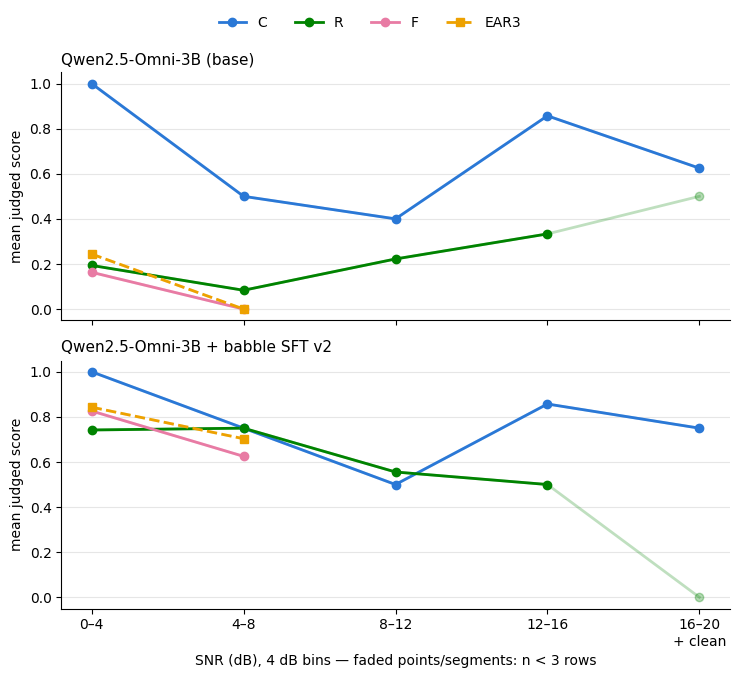

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

FILES = {
    "Qwen2.5-Omni-3B (base)": "bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
    "Qwen2.5-Omni-3B + babble SFT v2": "bab_results_Qwen2.5-Omni-3B-bab-sft-adapter-v2_slurp.jsonl",
}

EDGES = np.array([0.0, 4.0, 8.0, 12.0, 16.0, 20.0])
CENTERS = (EDGES[:-1] + EDGES[1:]) / 2
BIN_LABELS = ["0–4", "4–8", "8–12", "12–16", "16–20\n+ clean"]
KIND_METRIC = [("answer", "C"), ("repair", "R"), ("repair_full", "F")]
COLORS = {"C": "#2a78d6", "R": "#008300", "F": "#e87ba4", "EAR3": "#eda100"}
MIN_N = 3  # bins with fewer rows are drawn faded


def snr_bin(snr):
    if snr is None:  # clean audio -> treat as snr = inf, top bin
        return len(CENTERS) - 1
    return min(int(np.searchsorted(EDGES, snr, side="right")) - 1, len(CENTERS) - 1)


def harmonic3(c, r, f):
    d = c * r + c * f + r * f
    return 3.0 * c * r * f / d if d else 0.0


def plot_trend(ax, xs, ys, ns, color, label, ls="-", marker="o"):
    """Solid where both segment endpoints have n >= MIN_N; faded otherwise."""
    ax.plot(xs, ys, color=color, lw=2, ls=ls, alpha=0.25, zorder=1)
    for i in range(len(xs) - 1):
        if ns[i] >= MIN_N and ns[i + 1] >= MIN_N:
            ax.plot(xs[i:i + 2], ys[i:i + 2], color=color, lw=2, ls=ls, zorder=2)
    for x, y, n in zip(xs, ys, ns):
        ax.plot([x], [y], marker=marker, ms=6, color=color, lw=0,
                alpha=1.0 if n >= MIN_N else 0.3, zorder=3)
    ax.plot([], [], color=color, lw=2, ls=ls, marker=marker, ms=6, label=label)


fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.8), sharex=True, sharey=True)
for ax, (name, path) in zip(axes, FILES.items()):
    with open(path) as f:
        rows = [json.loads(l) for l in f]
    rows = [r for r in rows if r.get("type") != "summary"]

    means, nums = {}, {}
    for kind, metric in KIND_METRIC:
        by_bin = {}
        for r in rows:
            if r["kind"] == kind:
                by_bin.setdefault(snr_bin(r["snr_db"]), []).append(r["score"])
        means[metric] = {b: float(np.mean(s)) for b, s in by_bin.items()}
        nums[metric] = {b: len(s) for b, s in by_bin.items()}
        bins = sorted(means[metric])
        plot_trend(
            ax,
            [CENTERS[b] for b in bins],
            [means[metric][b] for b in bins],
            [nums[metric][b] for b in bins],
            COLORS[metric], metric,
        )

    # EAR3 only where all three kinds have rows in the same bin;
    # its per-bin n is the weakest of the three
    shared = sorted(set(means["C"]) & set(means["R"]) & set(means["F"]))
    if shared:
        plot_trend(
            ax,
            [CENTERS[b] for b in shared],
            [harmonic3(means["C"][b], means["R"][b], means["F"][b]) for b in shared],
            [min(nums[m][b] for m in ("C", "R", "F")) for b in shared],
            COLORS["EAR3"], "EAR3", ls="--", marker="s",
        )

    counts_readable = {m: {BIN_LABELS[b].replace("\n", " "): n
                           for b, n in sorted(nums[m].items())} for m in nums}
    print(f"{name} rows per bin: {counts_readable}")
    ax.set_title(name, fontsize=11, loc="left")
    ax.set_ylabel("mean judged score")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", color="0.9", lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.0))
axes[1].set_xticks(CENTERS, BIN_LABELS)
axes[1].set_xlabel(f"SNR (dB), 4 dB bins — faded points/segments: n < {MIN_N} rows")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
